# Regularization: Ridge and Lasso

In this lesson we address **overfitting** and **multicollinearity** using **Ridge** ($L_2$) and **Lasso** ($L_1$) regression. We will compare their effects on coefficients, tune the regularization strength with cross‑validation, and discuss when each is appropriate.

**Learning objectives**
- Understand how $L_2$ and $L_1$ penalties modify the OLS objective.
- Train and tune Ridge and Lasso with cross‑validation.
- Interpret **coefficient shrinkage** and **feature selection** effects.
- Read **validation curves** and **coefficient paths** as $\alpha$ varies.



## Why Regularize?

OLS minimizes
$$
\mathcal{L}_{\mathrm{OLS}}(\boldsymbol{\beta}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 \,,
\quad \text{with } \hat{y}_i = \beta_0 + \sum_{j=1}^p \beta_j x_{ij}.
$$

When features are **correlated** or $p$ is **large** relative to $n$, OLS can have **high variance**. Regularization adds a penalty on coefficient size to reduce variance at the cost of bias.

### Ridge ($L_2$) Regression
$$
\mathcal{L}_{\mathrm{Ridge}}(\boldsymbol{\beta}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \beta_j^2\,.
$$
- Shrinks coefficients **continuously** toward zero.
- Never sets coefficients **exactly** to zero.
- Good for **multicollinearity**.

### Lasso ($L_1$) Regression
$$
\mathcal{L}_{\mathrm{Lasso}}(\boldsymbol{\beta}) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \lvert \beta_j \rvert \,.
$$
- Encourages **sparsity**: can set some coefficients **exactly** to zero.
- Useful for **feature selection**.

The **regularization strength** $\alpha \ge 0$ controls shrinkage; larger $\alpha$ means stronger regularization.


In [2]:
# !pip install numpy pandas matplotlib scikit-learn

In [3]:
# Data setup: Diabetes dataset
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import pandas as pd

data = load_diabetes(as_frame=True)
df = data.frame.copy()
df.rename(columns={'target': 'disease_progression'}, inplace=True)

X = df.drop(columns=['disease_progression'])
y = df['disease_progression']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
df.head()

Train shape: (353, 10)  Test shape: (89, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0



## Standardization & Pipelines

Regularized linear models are sensitive to **feature scaling** because the penalty depends on coefficient magnitude.  
Although the Diabetes features are already standardized, we demonstrate a `Pipeline` with `StandardScaler` to encourage good practice (especially for future datasets).

In [4]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = np.logspace(-3, 3, 20)

ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    
    lasso_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=alpha, max_iter=10000))
    ])
    
    ridge_r2 = cross_val_score(ridge_model, X, y, cv=cv, scoring='r2')
    lasso_r2 = cross_val_score(lasso_model, X, y, cv=cv, scoring='r2')
    
    ridge_scores.append(ridge_r2.mean())
    lasso_scores.append(lasso_r2.mean())

best_ridge_alpha = alphas[np.argmax(ridge_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_scores)]

print("Best Ridge alpha:", best_ridge_alpha)
print("Best Lasso alpha:", best_lasso_alpha)

Best Ridge alpha: 26.366508987303554
Best Lasso alpha: 0.6951927961775606



**Reading CV curves**
- Choose the $\alpha$ that **maximizes** validation $R^2$ (or **minimizes** RMSE).
- Ridge curves are usually smoother; Lasso may plateau and then drop as many coefficients are zeroed out.


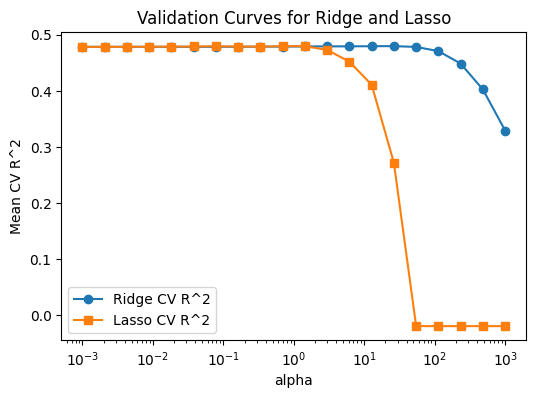

In [7]:
# Plot validation curves for Ridge and Lasso
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.semilogx(alphas, ridge_scores, marker='o', label='Ridge CV R^2')
plt.semilogx(alphas, lasso_scores, marker='s', label='Lasso CV R^2')
plt.xlabel("alpha")
plt.ylabel("Mean CV R^2")
plt.title("Validation Curves for Ridge and Lasso")
plt.legend()
plt.show()

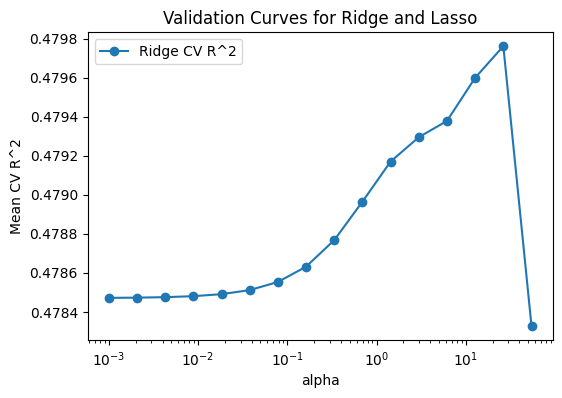

In [24]:
# Plot validation curves for Ridge and Lasso
import matplotlib.pyplot as plt
k=16
plt.figure(figsize=(6, 4))
plt.semilogx(alphas[:k], ridge_scores[:k], marker='o', label='Ridge CV R^2')
# plt.semilogx(alphas[:k], lasso_scores[:k], marker='s', label='Lasso CV R^2')
plt.xlabel("alpha")
plt.ylabel("Mean CV R^2")
plt.title("Validation Curves for Ridge and Lasso")
plt.legend()
plt.show()

In [25]:
# Fit best Ridge and Lasso models and evaluate on the test set
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

best_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=best_ridge_alpha))
])

best_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=best_lasso_alpha, max_iter=10000))
])

best_ridge.fit(X_train, y_train)
best_lasso.fit(X_train, y_train)

for name, model in [('Ridge', best_ridge), ('Lasso', best_lasso)]:
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"{name} (alpha={model.named_steps['model'].alpha:.4f})")
    print(f"  Test R^2: {r2:.3f}")
    print(f"  Test RMSE: {rmse:.3f}")
    print(f"  Test MAE: {mae:.3f}")

Ridge (alpha=26.3665)
  Test R^2: 0.459
  Test RMSE: 53.518
  Test MAE: 42.922
Lasso (alpha=0.6952)
  Test R^2: 0.463
  Test RMSE: 53.324
  Test MAE: 42.825



## Coefficient Paths

By tracking coefficients across a grid of $\alpha$ values, we can visualize **shrinkage** (Ridge) and **sparsity** (Lasso).

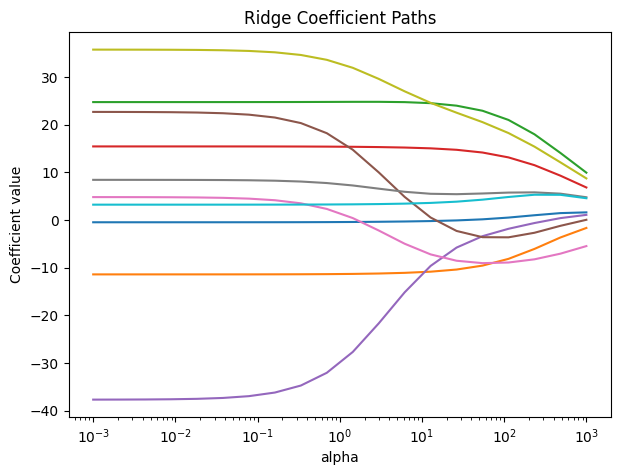

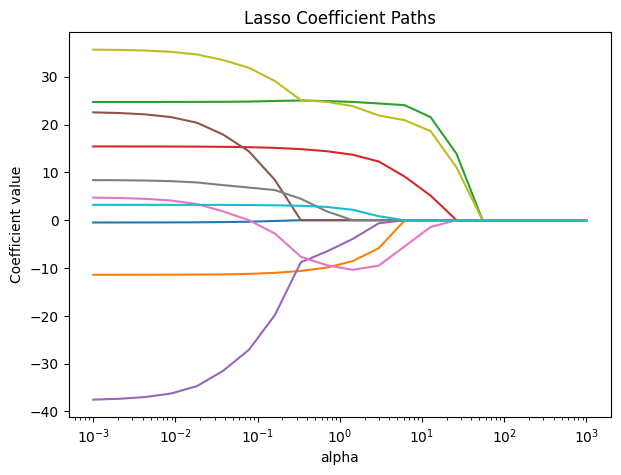

In [ ]:
# Coefficient paths for Ridge and Lasso
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns

# Ridge path
ridge_coefs = []
lasso_coefs = []
for a in alphas:
    Ridge(alpha=a).fit(X_scaled, y)
    ridge_coefs.append(Ridge(alpha=a).fit(X_scaled, y).coef_)
    Lasso(alpha=a, max_iter=10000).fit(X_scaled, y)
    lasso_coefs.append(Lasso(alpha=a, max_iter=10000).fit(X_scaled, y).coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(7,5))
for j in range(len(feature_names)):
    plt.semilogx(alphas, ridge_coefs[:, j])
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Paths")
plt.show()

plt.figure(figsize=(7,5))
for j in range(len(feature_names)):
    plt.semilogx(alphas, lasso_coefs[:, j])
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Paths")
plt.show()


**Interpreting paths**
- **Ridge:** all coefficients shrink smoothly toward $0$ as $\alpha$ increases.
- **Lasso:** coefficients hit **exactly $0$** at different $\alpha$ thresholds $\rightarrow$ implicit **feature selection**.



## Choosing Between Ridge and Lasso

- Use **Ridge** when many features have small/medium effects and multicollinearity is present.
- Use **Lasso** when you expect only a **subset** of features to be relevant and want **sparse** models.
- **Elastic Net** (not covered here) blends $L_1$ and $L_2$ and can be a good default when unsure.



## Exercises

1. **One‑SE rule:** Using the CV curves, pick the largest $\alpha$ within one standard error of the best $R^2$ (requires storing fold‑level scores). Does it generalize better?
2. **Sparsity check (Lasso):** For the chosen $\alpha$, how many coefficients are exactly zero? Which features remain?
3. **Target transform:** Try predicting $\log(1+y)$ instead of $y$. Does either model improve on $R^2$?
4. **Stability:** Shuffle `random_state` in K‑fold and report the variance in the selected $\alpha$ and test $R^2$.
